# Quickstart: ECMWF IFS ENS forecast, 46 day, 1.5 degree - dynamical.org Icechunk Zarr

ECMWF's Integrated Forecasting System (IFS) runs a sub-seasonal-range ensemble that reaches **46 days** ahead — far past the 15 days of the medium-range forecast. It trades resolution for reach: a 1.5 degree global grid, one 00 UTC run per day, a 24 hourly forecast step, and **101 ensemble members** to describe a forecast distribution that is much wider than at medium range.

That reach comes with a delay. ECMWF's licence holds sub-seasonal-range forecasts back for 48 hours, so this is not a real-time dataset — the newest initialization is about two days old.

Dataset documentation: https://dynamical.org/catalog/ecmwf-ifs-ens-forecast-46-day-1-5-degree/

**This dataset is under construction** and is published to the [staging catalog](https://stac-staging.dynamical.org/) only. Its `init_time` axis declares daily initializations back to 2023-06-28, but at the time of writing only **2026-07-25 through 2026-08-23** hold data; everything earlier reads as NaN. The cell below points `dynamical-catalog` at the staging catalog so it can find the dataset at all.

Dataset licenced [CC-BY-4.0](https://creativecommons.org/licenses/by/4.0/) and [ECMWF Terms of Use](https://apps.ecmwf.int/datasets/licences/general/).

In [ ]:
# If running locally, follow README.md for simple dependency installation.
# If using Google Colab, run this cell.
!uv pip install dynamical-catalog

In [2]:
import os

# This dataset is staging-only while its archive is under construction.
os.environ.setdefault("DYNAMICAL_STAC_CATALOG_URL", "https://stac-staging.dynamical.org/catalog.json")

import dynamical_catalog

ds = dynamical_catalog.open("ecmwf-ifs-ens-forecast-46-day-1-5-degree", chunks=None)
ds

<xarray.Dataset> Size: 18TB
Dimensions:                                         (init_time: 1153,
                                                     lead_time: 47,
                                                     ensemble_member: 101,
                                                     latitude: 121,
                                                     longitude: 240)
Coordinates:
  * init_time                                       (init_time) datetime64[ns] 9kB ...
    ingested_forecast_length                        (init_time) timedelta64[us] 9kB ...
    expected_forecast_length                        (init_time) timedelta64[us] 9kB ...
  * lead_time                                       (lead_time) timedelta64[us] 376B ...
    valid_time                                      (init_time, lead_time) datetime64[ns] 434kB ...
  * ensemble_member                                 (ensemble_member) int16 202B ...
  * latitude                                        (latitude) float64 968B 9...
  * longitude                                       (longitude) float64 2kB -...
    spatial_ref                                     int64 8B ...
Data variables: (12/29)
    average_dew_point_temperature_2m                (init_time, lead_time, ensemble_member, latitude, longitude) float32 636GB ...
    average_temperature_2m                          (init_time, lead_time, ensemble_member, latitude, longitude) float32 636GB ...
    downward_sensible_heat_flux_surface             (init_time, lead_time, ensemble_member, latitude, longitude) float32 636GB ...
    downward_latent_heat_flux_surface               (init_time, lead_time, ensemble_member, latitude, longitude) float32 636GB ...
    downward_short_wave_radiation_flux_surface      (init_time, lead_time, ensemble_member, latitude, longitude) float32 636GB ...
    eastward_turbulent_surface_stress               (init_time, lead_time, ensemble_member, latitude, longitude) float32 636GB ...
    ...                                              ...
    snow_water_equivalent_surface                   (init_time, lead_time, ensemble_member, latitude, longitude) float32 636GB ...
    soil_moisture_0_100cm                           (init_time, lead_time, ensemble_member, latitude, longitude) float32 636GB ...
    soil_temperature_0_20cm                         (init_time, lead_time, ensemble_member, latitude, longitude) float32 636GB ...
    total_column_water_atmosphere                   (init_time, lead_time, ensemble_member, latitude, longitude) float32 636GB ...
    total_cloud_cover_atmosphere                    (init_time, lead_time, ensemble_member, latitude, longitude) float32 636GB ...
    soil_temperature_0_100cm                        (init_time, lead_time, ensemble_member, latitude, longitude) float32 636GB ...
Attributes:
    dataset_id:           ecmwf-ifs-ens-forecast-46-day-1-5-degree
    dataset_version:      0.1.0
    name:                 ECMWF IFS ENS forecast, 46 day, 1.5 degree
    description:          Sub-seasonal-range ensemble weather forecasts from ...
    attribution:          ECMWF IFS ENS sub-seasonal-range forecast data proc...
    license:              CC-BY-4.0
    spatial_domain:       Global
    spatial_resolution:   1.5 degrees (~165km)
    time_domain:          Forecasts initialized 2023-06-28 00:00:00 UTC to Pr...
    time_resolution:      Forecasts initialized every 24 hours
    forecast_domain:      Forecast lead time 0-1104 hours (0-46 days) ahead
    forecast_resolution:  Forecast step 24 hourly

This is a forecast dataset with two time dimensions — `init_time` (when the run began) and `lead_time` (how far ahead it reaches) — plus `ensemble_member`, `latitude` and `longitude`. The `valid_time` coordinate combines the two time dimensions to give the actual forecasted time.

Four things are worth knowing before you start:

- **The 0 hour lead time carries no surface data.** At a 24 hourly step most surface fields are 24 hour means or mean rates — which is what the `average_` prefix marks — and a 24 hour statistic needs a preceding day. 27 of the 29 root variables are entirely NaN at `lead_time=0`; only `pressure_reduced_to_mean_sea_level` and `pressure_surface`, which are instantaneous, have values there. `lead_time=slice("24h", None)` is the safe default.
- **Variables on pressure levels live in a group.** Surface and single-level variables are at the dataset root; temperature, specific humidity, both wind components, vertical velocity and geopotential height are in the `pressure_level` group, on 10 levels from 1000 to 10 hPa. These are instantaneous, so they *do* have a 0 hour lead time.
- **Some variables are masked to their domain.** Sea surface temperature and sea ice read NaN over land; soil and runoff fields read NaN over ocean; snow albedo and density read NaN where there is no snow.
- **One chunk holds every lead time and every member** for a 25 x 24 patch of the grid. A 46 day series at a point is therefore cheap, and regional maps stay cheap too, but be aware that reading a single grid cell decodes all 47 lead times and all 101 members behind it.

In [3]:
# Temperature, humidity, wind, vertical velocity and geopotential height are on pressure levels
ds_pressure = dynamical_catalog.open(
    "ecmwf-ifs-ens-forecast-46-day-1-5-degree", group="pressure_level", chunks=None
)
ds_pressure

<xarray.Dataset> Size: 38TB
Dimensions:                   (init_time: 1153, lead_time: 47,
                               ensemble_member: 101, pressure_level: 10,
                               latitude: 121, longitude: 240)
Coordinates:
  * init_time                 (init_time) datetime64[ns] 9kB 2023-06-28 ... 2...
    expected_forecast_length  (init_time) timedelta64[us] 9kB ...
    ingested_forecast_length  (init_time) timedelta64[us] 9kB ...
  * lead_time                 (lead_time) timedelta64[us] 376B 0 days ... 46 ...
    valid_time                (init_time, lead_time) datetime64[ns] 434kB ...
  * ensemble_member           (ensemble_member) int16 202B 0 1 2 3 ... 98 99 100
  * pressure_level            (pressure_level) int64 80B 1000 925 850 ... 50 10
  * latitude                  (latitude) float64 968B 90.0 88.5 ... -88.5 -90.0
  * longitude                 (longitude) float64 2kB -180.0 -178.5 ... 178.5
    spatial_ref               int64 8B ...
Data variables:
    geopotential_height       (init_time, lead_time, ensemble_member, pressure_level, latitude, longitude) float32 6TB ...
    temperature               (init_time, lead_time, ensemble_member, pressure_level, latitude, longitude) float32 6TB ...
    vertical_velocity         (init_time, lead_time, ensemble_member, pressure_level, latitude, longitude) float32 6TB ...
    specific_humidity         (init_time, lead_time, ensemble_member, pressure_level, latitude, longitude) float32 6TB ...
    wind_v                    (init_time, lead_time, ensemble_member, pressure_level, latitude, longitude) float32 6TB ...
    wind_u                    (init_time, lead_time, ensemble_member, pressure_level, latitude, longitude) float32 6TB ...
Attributes:
    dataset_id:           ecmwf-ifs-ens-forecast-46-day-1-5-degree
    dataset_version:      0.1.0
    name:                 ECMWF IFS ENS forecast, 46 day, 1.5 degree
    description:          Sub-seasonal-range ensemble weather forecasts from ...
    attribution:          ECMWF IFS ENS sub-seasonal-range forecast data proc...
    license:              CC-BY-4.0
    spatial_domain:       Global
    spatial_resolution:   1.5 degrees (~165km)
    time_domain:          Forecasts initialized 2023-06-28 00:00:00 UTC to Pr...
    time_resolution:      Forecasts initialized every 24 hours
    forecast_domain:      Forecast lead time 0-1104 hours (0-46 days) ahead
    forecast_resolution:  Forecast step 24 hourly

### 101 traces, 46 days

At sub-seasonal range no single member is a forecast — the ensemble as a whole is. Here are all 101 members of one run at a point, with the control member in black.

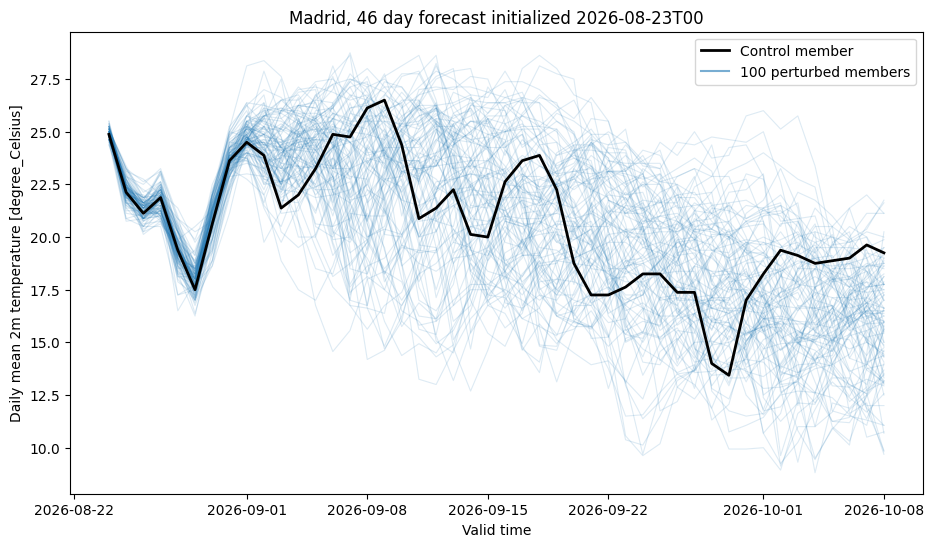

In [4]:
import matplotlib.pyplot as plt

# The newest initialization holding data while the archive is under construction.
INIT = "2026-08-23T00"

# Madrid. Surface fields have no 0 hour lead time, so start the selection at 24 hours.
madrid = ds.sel(init_time=INIT, latitude=40.4, longitude=-3.7, method="nearest")
temperature = madrid["average_temperature_2m"].sel(lead_time=slice("24h", None)).load()

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(
    temperature.valid_time,
    temperature.sel(ensemble_member=slice(1, 100)).transpose("lead_time", "ensemble_member"),
    color="tab:blue", alpha=0.15, linewidth=0.8,
)
ax.plot(
    temperature.valid_time, temperature.sel(ensemble_member=0),
    color="black", linewidth=2, label="Control member",
)
ax.plot([], [], color="tab:blue", alpha=0.6, label="100 perturbed members")
ax.legend()
_ = ax.set(
    xlabel="Valid time", ylabel=f"Daily mean 2m temperature [{temperature.attrs['units']}]",
    title=f"Madrid, 46 day forecast initialized {INIT}",
)

### Spread grows, then saturates

The useful way to read that fan is as a distribution. Quantiles across the 101 members show the forecast widening over the first couple of weeks and then settling — past roughly day 15 the ensemble stops telling you about individual days and starts telling you about the period.

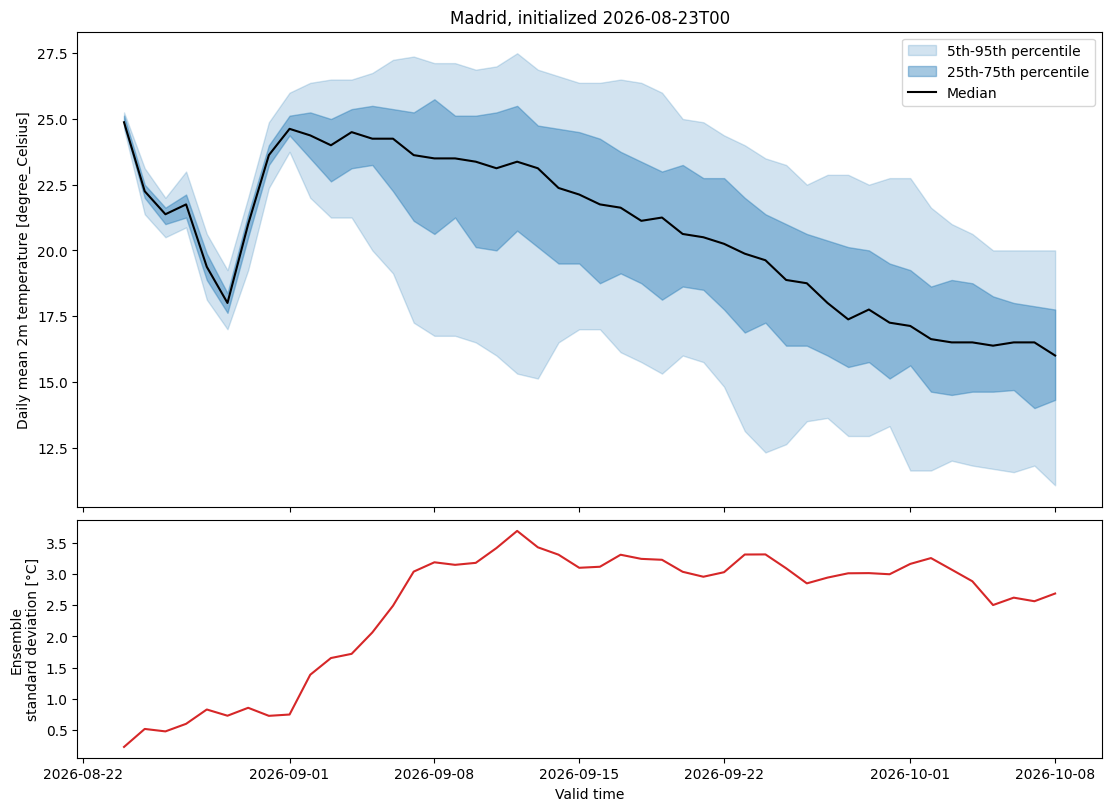

In [5]:
quantiles = temperature.quantile([0.05, 0.25, 0.5, 0.75, 0.95], dim="ensemble_member")
valid_time = temperature.valid_time

fig, (ax, ax_spread) = plt.subplots(
    2, 1, figsize=(11, 8), sharex=True, height_ratios=[2, 1], constrained_layout=True
)
ax.fill_between(
    valid_time, quantiles.sel(quantile=0.05), quantiles.sel(quantile=0.95),
    alpha=0.2, color="tab:blue", label="5th-95th percentile",
)
ax.fill_between(
    valid_time, quantiles.sel(quantile=0.25), quantiles.sel(quantile=0.75),
    alpha=0.4, color="tab:blue", label="25th-75th percentile",
)
ax.plot(valid_time, quantiles.sel(quantile=0.5), color="black", label="Median")
ax.legend()
ax.set(ylabel=f"Daily mean 2m temperature [{temperature.attrs['units']}]", title=f"Madrid, initialized {INIT}")

ax_spread.plot(valid_time, temperature.std("ensemble_member"), color="tab:red")
_ = ax_spread.set(xlabel="Valid time", ylabel="Ensemble\nstandard deviation [°C]")

### Weekly means are the sub-seasonal unit

Because the day-to-day signal is gone well before day 46, sub-seasonal forecasts are normally used as weekly (or fortnightly) aggregates, and read as probabilities rather than values. Averaging each member over each forecast week and then counting members gives exactly that.

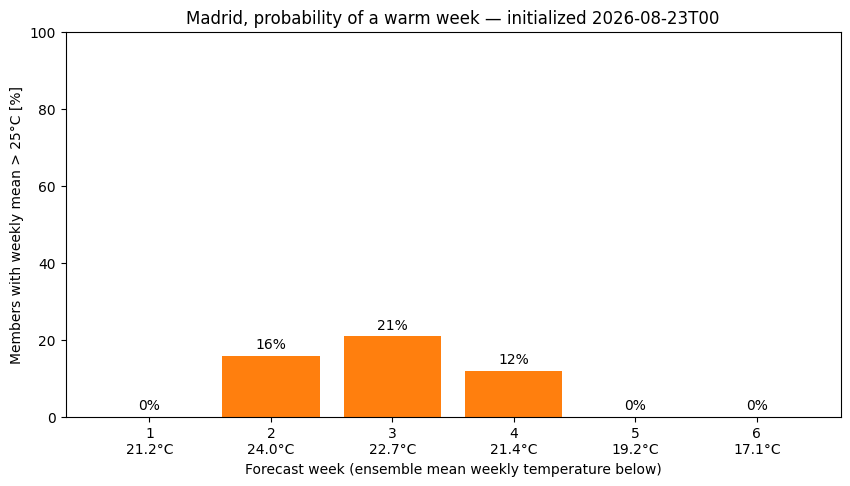

In [6]:
# Group the 46 daily steps into forecast weeks. Weeks 1-6 are complete (days 1-42).
forecast_week = ((temperature.lead_time.dt.days - 1) // 7) + 1
weekly = (
    temperature.assign_coords(week=("lead_time", forecast_week.data))
    .groupby("week").mean("lead_time")
    .sel(week=slice(1, 6))
)

THRESHOLD = 25.0  # degrees Celsius
probability = (weekly > THRESHOLD).mean("ensemble_member") * 100

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(weekly.week, probability, color="tab:orange")
ax.bar_label(bars, fmt="%.0f%%", padding=3)
ax.set_xticks(weekly.week)
ax.set_xticklabels(
    f"{week}\n{mean:.1f}°C"
    for week, mean in zip(weekly.week.values, weekly.mean("ensemble_member").values)
)
_ = ax.set(
    xlabel="Forecast week (ensemble mean weekly temperature below)",
    ylabel=f"Members with weekly mean > {THRESHOLD:.0f}°C [%]",
    ylim=(0, 100), title=f"Madrid, probability of a warm week — initialized {INIT}",
)

### Where is the forecast confident?

The same two numbers — ensemble mean and ensemble spread — map usefully. Below is forecast **week 4** (days 22 to 28), a lead time no medium-range model reaches. The spread panel is the more interesting one: it shows where the ensemble still agrees a month out, and where it has given up.

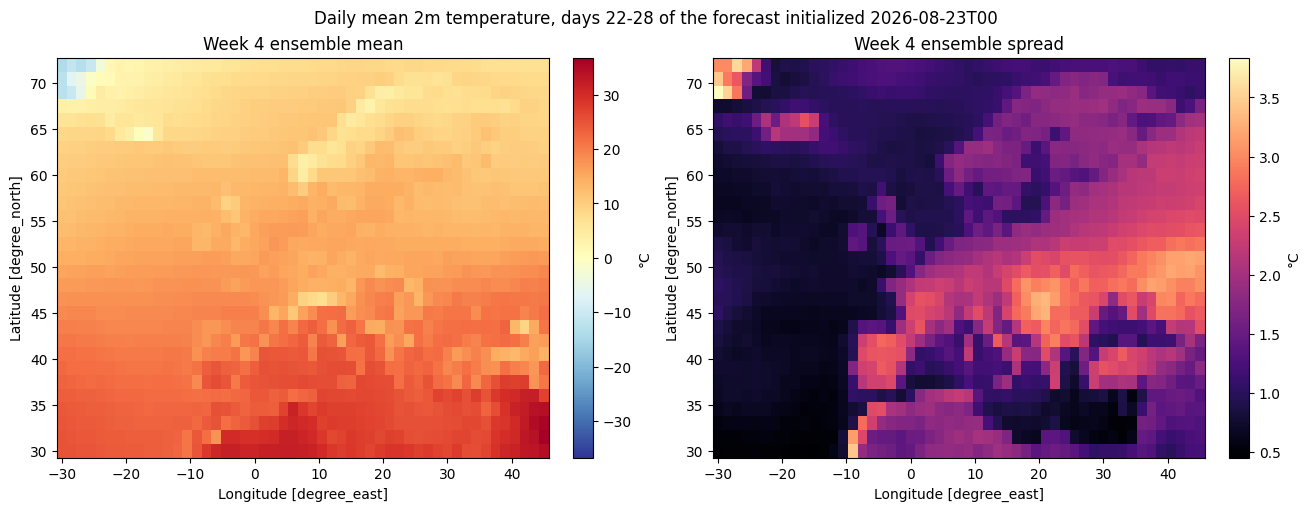

In [7]:
week_4 = (
    ds["average_temperature_2m"]
    .sel(init_time=INIT, lead_time=slice("22d", "28d"), latitude=slice(72, 30), longitude=slice(-30, 45))
    .load()
    .mean("lead_time")
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
week_4.mean("ensemble_member").plot(ax=axes[0], cmap="RdYlBu_r", cbar_kwargs={"label": "°C"})
axes[0].set_title("Week 4 ensemble mean")
week_4.std("ensemble_member").plot(ax=axes[1], cmap="magma", cbar_kwargs={"label": "°C"})
axes[1].set_title("Week 4 ensemble spread")
_ = fig.suptitle(f"Daily mean 2m temperature, days 22-28 of the forecast initialized {INIT}")

### The large scale flow, from the pressure level group

Geopotential height on the 500 hPa surface shows the ridges and troughs that steer weather systems. Ten days ahead the ensemble mean still has recognizable structure, and the spread shows which parts of it the members disagree about.

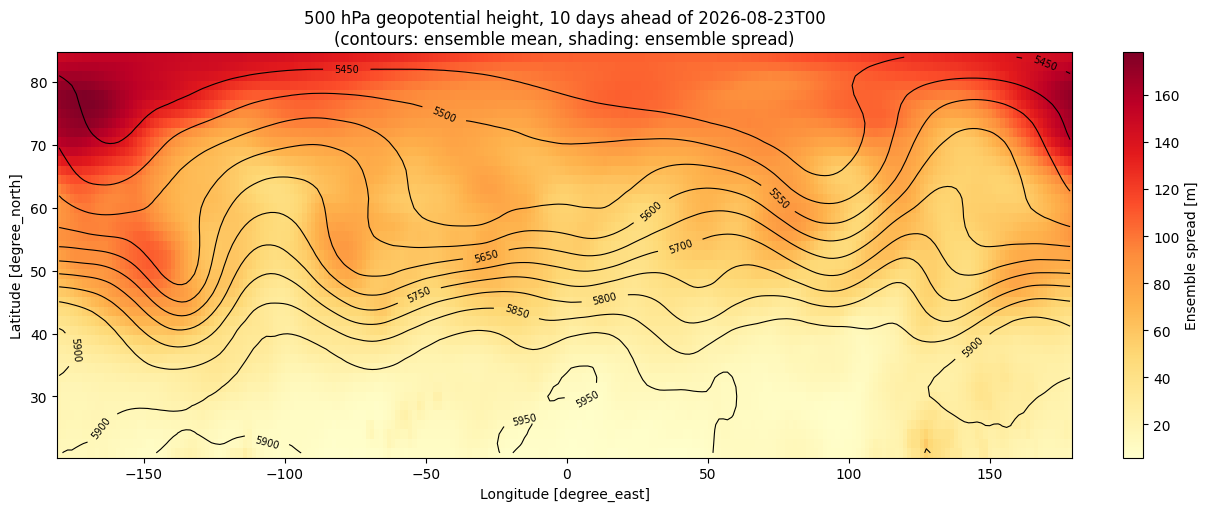

In [8]:
height_500 = ds_pressure["geopotential_height"].sel(
    init_time=INIT, lead_time="10d", pressure_level=500, latitude=slice(85, 20)
).load()

fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
height_500.std("ensemble_member").plot(
    ax=ax, cmap="YlOrRd", cbar_kwargs={"label": "Ensemble spread [m]"}
)
contours = ax.contour(
    height_500.longitude, height_500.latitude, height_500.mean("ensemble_member"),
    levels=12, colors="black", linewidths=0.8,
)
ax.clabel(contours, inline=True, fontsize=7, fmt="%d")
_ = ax.set_title(f"500 hPa geopotential height, 10 days ahead of {INIT}\n(contours: ensemble mean, shading: ensemble spread)")

### Masked variables

Several variables only exist over part of the globe and read as NaN elsewhere. Sea surface temperature is the clearest case — it is a sea field, so the continents are empty.

NaN fraction: 33.8%


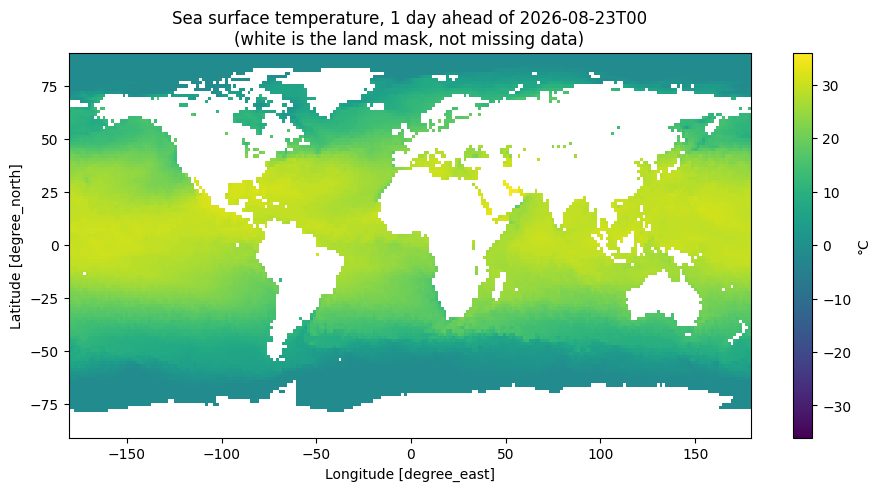

In [9]:
import numpy as np

sea_surface_temperature = (
    ds["sea_surface_temperature"].sel(init_time=INIT, lead_time="1d").isel(ensemble_member=0).load()
)
print(f"NaN fraction: {float(np.isnan(sea_surface_temperature).mean()):.1%}")

mesh = sea_surface_temperature.plot(figsize=(11, 5), cmap="viridis", cbar_kwargs={"label": "°C"})
_ = mesh.axes.set_title(f"Sea surface temperature, 1 day ahead of {INIT}\n(white is the land mask, not missing data)")